# Machine learning

This notebook introduces some of the most commonly used machine learning techniques for processing 3D pointclouds. Unlike purely geometric approaches, these methods leverage both geometric structure and **statistical properties** of the data while remaining **interpretable and efficient**.

Machine learning algorithms often outperform classical methods for tasks such as **outlier detection** and **object segmentation**, and naturally extend to more advanced applications like **semantic segmentation**.

In [1]:
# Necessary imports
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KDTree, kneighbors_graph, LocalOutlierFactor
from sklearn.cluster import MiniBatchKMeans, DBSCAN, AgglomerativeClustering
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

## Cleaning

As a reminder, the goal of cleaning is to reduce both the number of outliers and the level of noise affecting a pointcloud, as these can impact subsequent processing steps (see the notebook on cleaning). 

From a machine learning perspective, outlier detection can be framed as a subtask of **unsupervised learning**, often referred to as **anomaly detection**, where the goal is to find points that are "different" from the rest of the data, without using labeled examples.

Although there is a lot of work on *anomaly detection*, this section focuses on the **Local Outlier Factor (LOF)**, which extends the neighborhood-based principles of traditional techniques in a more adaptive way.

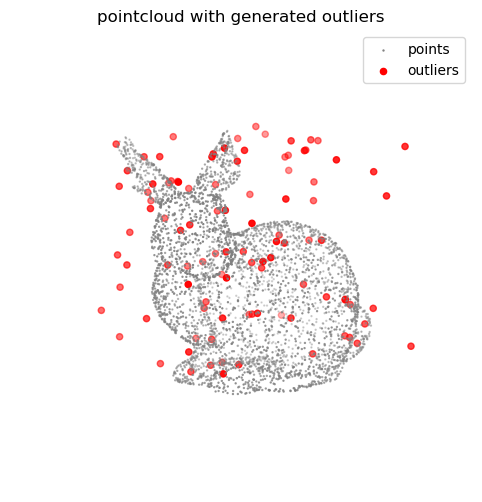

In [2]:
# Load our bunny pointcloud
data = np.loadtxt("./data/stanford_bunny_custom.xyz")
points = data[:, :3]
normals = data[:, 9:12]

# Add outliers to the pointcloud
n_outliers = 100
outliers = np.random.uniform(
    points.min(axis=0),
    points.max(axis=0),
    (n_outliers, 3)
)
points_outliers = np.vstack((points, outliers))
# Create a mask to identify the outliers in the combined pointcloud
outliers_mask_true = np.hstack((np.zeros(points.shape[0], dtype=bool),
                                np.ones(outliers.shape[0], dtype=bool)))

# Visualize the pointcloud with outliers
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c="grey", s=0.5, label="points")
ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2],
           c="red", label="outliers")
ax.set_box_aspect([1, 1, 1])
ax.view_init(10, 60)
ax.set_axis_off()
ax.legend()
ax.set_title("pointcloud with generated outliers")
plt.show()

The most commonly used traditional outlier detection techniques, namely *Statistical Outlier Removal* (SOR) and *Radius Outlier Removal* (ROR), rely on the assumption of a globally consistent point density, using fixed thresholds based on distances or neighborhood sizes to identify outliers. As a result, they often struggle when the density varies across the pointcloud, since a single global criterion cannot adapt to heterogeneous regions. A natural improvement is therefore to account for local variations in the data distribution rather than applying a uniform rule.

This is precisely the idea behind the **Local Outlier Factor (LOF)**, which adopts an **unsupervised learning approach** by estimating the local density of each point and comparing it to that of its neighbors \cite{breunig2000lof}. By relying on relative density instead of absolute thresholds, LOF is able to automatically adapt to spatial heterogeneity and detect more subtle anomalies in complex pointclouds.

LOF can be applied directly to point coordinates or extended to higher-dimensional feature spaces by incorporating additional attributes such as intensity, color, normals, or eigenvalue-based descriptors. This is an additional advantage over more traditional techniques that rely solely on geometric Euclidean distances. However, careful feature selection and proper data normalization are essential to ensure meaningful results.

LOF computation for given point $p_{i}$ follows these steps:

1. Query the $k$-nearest neighbors of $p_{i}$ and form the set $N_{i}$.

2. Compute the $k$-distance of each neighbor $p_{j} \in N_{i}$, which corresponds to the distance between $p_{j}$​ and its $k$-th nearest neighbor:
\begin{equation*}
    k\text{-dist}(p_{j})
\end{equation*}

3. Define the reachability distance between $p_i$​ and each neighbor $p_j$:
\begin{equation*}
    \text{reach-dist}_{k}(p_{i}, p_{j}) = \max (k\text{-dist}(p_{j}), d(p_{i}, p_{j}))
\end{equation*}

4. Estimate the local reachability density (LRD) of $p_{i}$​:
\begin{equation*}
    LRD_{k}(p_{i}) = (\frac{1}{|N_{i}|} \sum_{p_{j} \in N_{i}} \text{reach-dist}_{k}(p_{i}, p_{j}))^{-1}
\end{equation*}

5. Compute the Local Outlier Factor (LOF) of $p_{i}$​ by comparing its density to that of its neighbors
\begin{equation*}
    LOF_{k}(p_{i}) = \frac{1}{|N_{i}|} \sum_{p_{j} \in N_{i}} \frac{LRD_{k}(p_{j})}{LRD_{k}(p_{i})}
\end{equation*}

As a result, LOF assigns a score to each point measuring how isolated it is with respect to its local neighborhood. Values close to 1 indicate inliers, while significantly larger values indicate potential outliers.

LOF is conceptually straightforward and can be directly implemented using Python main scientific libraries. The ```scikit-learn``` library also provides an out-of-the box implementation called ```LocalOutlierFactor```, which is used in the example below.

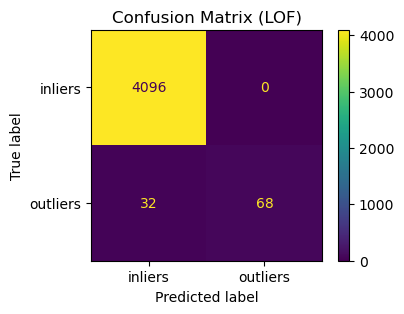

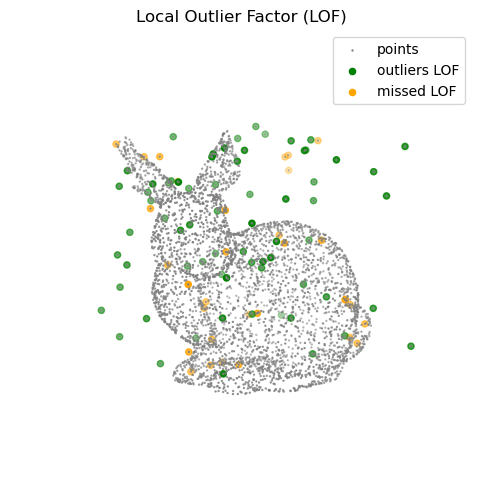

In [3]:
# Detect outliers using Local Outlier Factor (LOF)
clf_lof = LocalOutlierFactor(n_neighbors=10)
y_pred = clf_lof.fit_predict(points_outliers)
outlier_mask_lof = y_pred == -1
outliers_lof = points_outliers[outlier_mask_lof]
missed_mask_lof = np.logical_xor(outlier_mask_lof, outliers_mask_true)
missed_lof = points_outliers[missed_mask_lof]

# Evaluate the performance of LOF using a confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
cmd_lof = ConfusionMatrixDisplay.from_predictions(
    outliers_mask_true, outlier_mask_lof,
    display_labels=["inliers", "outliers"],
    ax=ax
)
ax.set_title("Confusion Matrix (LOF)")
plt.show()

# Visualize the inliers and outliers
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_outliers[:, 0], points_outliers[:, 1], points_outliers[:, 2],
           c="grey", s=0.5, label="points")
ax.scatter(outliers_lof[:, 0], outliers_lof[:, 1], outliers_lof[:, 2],
           c="green", label="outliers LOF")
ax.scatter(missed_lof[:, 0], missed_lof[:, 1], missed_lof[:, 2],
           c="orange", label="missed LOF")
ax.set_box_aspect([1, 1, 1])
ax.view_init(10, 60)
ax.set_axis_off()
ax.legend()
ax.set_title("Local Outlier Factor (LOF)")
plt.show()

## Object Segmentation

As a reminder, object segmentation in 3D pointclouds aims to group points that belong to the same physical object. In practice, each object corresponds to a set of nearby points and segmentation seeks to identify and separate these sets. 

This goal is closely aligned with **clustering**, a core concept in **unsupervised learning**, which consists of partition data into groups based on similarity without relying on labeled examples. As a result, clustering algorithms provide a natural and flexible framework for object segmentation.

The following subsections explore how classical clustering methods such as KMeans, DBSCAN, and Agglomerative Clustering can be applied to segment 3D pointclouds.

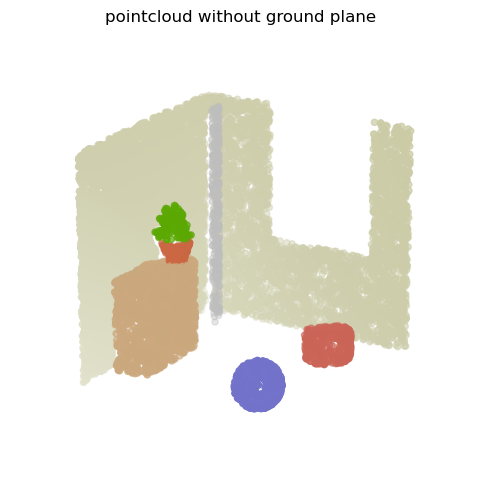

In [4]:
# Load synthetic indoor scene pointcloud
data = np.loadtxt("./data/indoor_scene.xyz")
points, colors, normals = data[:, :3], data[:, 6:9], data[:, 9:12]

# Remove points belonging to the ground plane (z = 0)
ground_mask = points[:, 2] < 0.05
points_no_ground = points[~ground_mask]
colors_no_ground = colors[~ground_mask]
normals_no_ground = normals[~ground_mask]

# Visualize the original pointcloud and the points without the ground plane
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_no_ground[:, 0], points_no_ground[:, 1], points_no_ground[:, 2],
            c=colors_no_ground)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=210)
ax.set_axis_off()
ax.set_title("pointcloud without ground plane")
plt.show()


### K-means

KMeans is one of the most widely used clustering algorithms and is sometimes considered for object segmentation in 3D point clouds. It **partitions the data into a fixed number of clusters by minimizing the distance between each point and its assigned cluster centroid**.

Because KMeans tends to produce compact and roughly spherical clusters, it is rarely applied to raw spatial coordinates alone. Instead, it is typically used with enriched feature representations, combining position with attributes such as color or intensity. In practice, careful feature selection and proper normalization are essential to ensure stable and meaningful results.

However, the reliance on centroid distance introduces several important limitations. Nearby objects may be grouped into a single cluster, and the method implicitly **assumes clusters of similar size and convex shape**. It does not enforce spatial continuity and struggles with varying point densities, which are common in real-world data. In addition, the number of clusters must be specified *a priori*, although heuristic methods such as the *elbow curve* can help estimate a suitable value *a posteriori*.

These limitations make KMeans not much used in practice for complex scenes. The example below even underlines its limitation on our rather simple synthetic indoor scene. Note that the implementation below uses ```MiniBatchKMeans```, which is a variant of the KMeans algorithm which uses mini-batches to reduce the computation time. A ```StandardScaler``` is applied to normalize the features.

c:\Users\frup00090363\AppData\Local\miniconda3\envs\sci\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


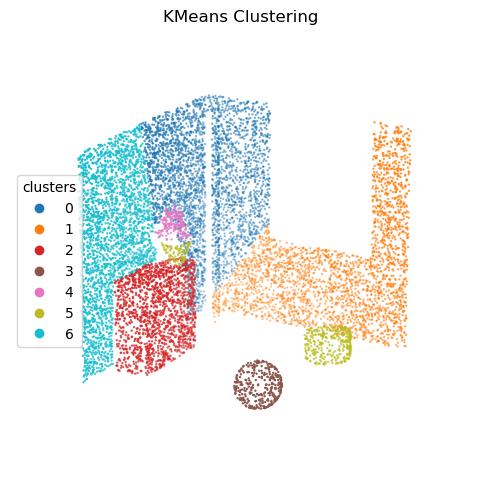

In [5]:
# Stack points and colors into a feature matrix X
X_kmeans = np.hstack((points_no_ground, colors_no_ground))
# Standardize features
X_kmeans = StandardScaler().fit_transform(X_kmeans)
# KMeans clustering with a chosen number of clusters
labels_kmeans = MiniBatchKMeans(n_clusters=7, n_init=10).fit_predict(X_kmeans)

# Visualize KMeans clustering results
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points_no_ground[:, 0], points_no_ground[:, 1], points_no_ground[:, 2],
                     c=labels_kmeans, cmap="tab10", s=0.5)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=210)
ax.set_axis_off()
ax.set_title("KMeans Clustering")
ax.legend(*scatter.legend_elements(), title="clusters", loc="center left")
plt.show()

### DBSCAN

DBSCAN is a density-based clustering algorithm that is particularly well-suited for 3D pointclouds. It groups points based on spatial proximity and local density, using a distance threshold to connect neighboring points. Unlike KMeans, DBSCAN does not require specifying the number of clusters in advance and can naturally detect outliers as noise, making it robust in cluttered scenes.

Additional features such as color or normals can help better separate objects, but they also increase the feature space dimension. In high dimensions, distances become less meaningful and neighborhoods more sparse, which can degrade performance. To address this, it is common to either weight features carefully or decouple the problem (for example, first clustering in XYZ space, then refining clusters using additional features).

The implementation below uses the ```DBSCAN``` algorithm from ```scikit-learn```.

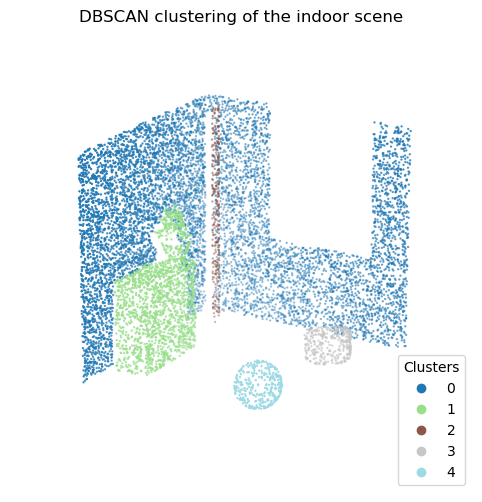

In [6]:
# DBSCAN clustering to segment the scene
labels_dbscan = DBSCAN(eps=100., min_samples=20).fit_predict(points_no_ground)

# Visualize the clustered pointcloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points_no_ground[:, 0], points_no_ground[:, 1], points_no_ground[:, 2],
                     c=labels_dbscan, cmap="tab20", s=0.5)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=210)
ax.set_axis_off()
ax.set_title("DBSCAN clustering of the indoor scene")
ax.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

### Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering method that progressively builds clusters by merging nearby points or groups of points. Starting from individual points, it iteratively combines the closest clusters according to a chosen linkage criterion, producing a hierarchy that can be cut at different levels to obtain a segmentation.

A key advantage for pointcloud segmentation is the ability to incorporate a connectivity matrix, which restricts merges to spatially neighboring points and helps preserve local structure. This makes the method well-suited for refining structured regions such as walls, roofs, or indoor partitions. However, its computational cost is high, which makes it more appropriate as a refinement step rather than a first clustering approach. Agglomerative clustering also sometimes used in surface segmentation and simplification \cite{pauly2002efficient}, following the same strategy of merging groups of points based on similarity.

The implementation below uses the ```AgglomerativeClustering``` algorithm from ```scikit-learn```. A ```kneighbors_graph``` is used to define connectivity and a ```StandardScaler``` is applied to normalize the features.

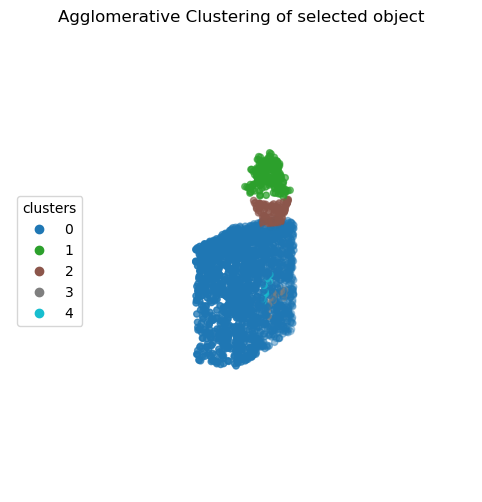

In [7]:
# Select a cluster of interest from the DBSCAN results
object_mask = labels_dbscan == 1
points_object = points_no_ground[object_mask]
points_object -= points_object.mean(axis=0)  # center the object 
normals_object = normals_no_ground[object_mask]
colors_object = colors_no_ground[object_mask]

# Stack features for Agglomerative Clustering (only normals and colors)
X_agglo = np.hstack((normals_object, colors_object))
X_agglo = StandardScaler().fit_transform(X_agglo)
# Compute the connectivity matrix from the coordinates of the points
connectivity = kneighbors_graph(points_object, n_neighbors=10, mode='connectivity', include_self=False)
# Perform Agglomerative Clustering with connectivity constraints
labels_agglo = AgglomerativeClustering(
    n_clusters=5,
    connectivity=connectivity,
    linkage="ward"
    ).fit_predict(X_agglo)

# Visualize Agglomerative Clustering results
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points_object[:, 0], points_object[:, 1], points_object[:, 2],
                     c=labels_agglo, cmap="tab10")
ax.view_init(elev=20, azim=210)
ax.set_axis_off()
ax.set_title("Agglomerative Clustering of selected object")
ax.legend(*scatter.legend_elements(), title="clusters", loc="center left")
plt.axis("equal")
plt.show()


## Semantic Segmentation

In machine learning, semantic segmentation is a task within **supervised learning**, where a model is trained on labeled data to assign a class to each individual element of an input. Applied to 3D point clouds, **semantic segmentation consists of predicting a semantic label** (e.g., *car*, *tree*, *road*) **for every point**. This point-wise labeling enables a better interpretation of the meaning of 3D scenes.

Thanks to their ability to learn complex patterns and contextual information from labeled data, machine learning models can go beyond simple geometric rules to infer high-level semantic information. This makes them well-suited for segmenting complex 3D scenes, including urban and natural environments as well as indoor spaces.

In a "traditional" machine learning framework (excluding deep learning), semantic segmentation is typically structured into four key steps:

1. Definition of **neighborhoods** around each point to capture its local context

2. Computation of **descriptors** that describe the geometry of these neighborhoods

3. Selection and tuning of a **classifier** to assign a semantic label based on these descriptors

4. Contextual **regularization** to enforce spatial consistency of the predictions (Optional)

The design of efficient neighborhoods, discriminative descriptors, suitable classifiers, and spatial regularization strategies for semantic segmentation has been extensively explored in the literature \cite{demantke2011dimensionality, niemeyer2014contextual, weinmann2015semantic, hackel2016fast}. The following paragraphs try to summarize key practical insights derived from these works.

The example below comes from the IGN LiDAR HD dataset, a dense airborne LiDAR dataset providing a detailed 3D representation of landscapes in France, with an average density of about 10 points per square meter \cite{ign_lidar_hd}. The original pointcloud is classified into 11 categories, including eight standard ASPRS classes and three custom classes. For clarity and to reduce complexity, the point cloud is simplified to three classes (*ground*, *vegetation*, and *building*) by merging vegetation subclasses (*low*, *medium*, and *high vegetation*) and excluding less relevant categories such as *water* and *not classified*.

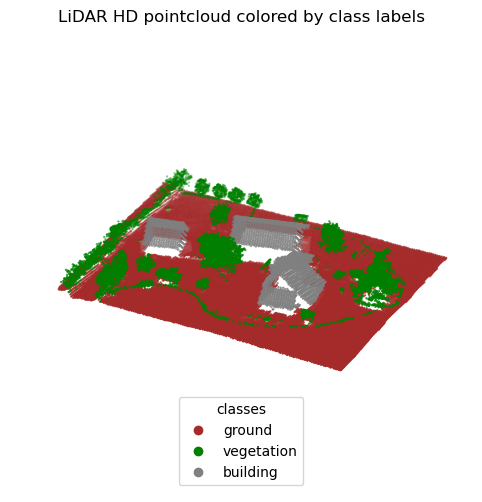

In [8]:
# Load LHD training data
data = np.loadtxt("./data/LHD_train.xyz", dtype=np.float32)
points, intensity, y_train = data[:, :3], data[:, 3], data[:, 4]
class_names = {0: "ground", 1: "vegetation", 2: "building"}

# Spatial structure
kdtree = KDTree(points)

# Visualize the pointcloud colored by class labels
lidar_cmap = matplotlib.colors.ListedColormap(["brown", "green", "gray"])
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=y_train, cmap=lidar_cmap, s=0.5)
ax.set_aspect("equal")
ax.view_init(elev=30)
ax.set_axis_off()
ax.set_title("LiDAR HD pointcloud colored by class labels")
# Create legend with class names
legend_handles = []
legend_labels = []
for cls in class_names.keys():
    color = lidar_cmap(cls)
    legend_handles.append(plt.Line2D([0], [0], marker='o', linestyle='',
                                     color=color, markersize=6))
    legend_labels.append(class_names[int(cls)])
ax.legend(legend_handles, legend_labels, title="classes", loc="lower center")
plt.show()


### Neighborhoods

The first step of the semantic segmentation pipeline is the **definition of neighborhoods**, which directly impacts the scale of the analysis.

There are several definitions of neighborhoods available in the literature, which can be categorized along two main aspects: their **nature** (geometric support) and their **scale** (size).

Common neighborhood types include:

* **$k$-neighborhoods**, defined by the $k$ closest points. They adapt to varying point density but give regions of different sizes.

* **Spherical neighborhoods**, consisting of all points within a 3D sphere of given radius around a point. They keep the size consistent but are sensitive to density variations.

* **Cylindrical neighborhoods**, where points are selected based on their projection within a circle on a plane (e.g., ground plane). They suit structured scenes but may miss some 3D information.

* **Voxel-based neighborhoods**, using grid cells (voxels). They allow efficient processing but depend strongly on the chosen grid size.

Common neighborhood scale selection strategies include:

* **Fixed-scale neighborhoods**, using a constant radius or a fixed number of neighbors. They are simple to apply but may not adapt well to varying densities or object sizes.

* **Adaptive single-scale neighborhoods**, where the optimal size is chosen for each point based on local properties. They better capture local geometry but require additional computation.

* **Multi-scale neighborhoods**, where features are computed at several predefined scales. They capture both fine and coarse structures but increase the computational cost and feature dimensionality.

* **Adaptive multi-scale neighborhoods**, combining multiple scales with data-driven selection or weighting. They offer flexibility and robustness but are more complex to design and compute.

The example below shows a popular adaptative single-scale strategy with $k$-neighborhoods.

It consists in determining for each point the optimal number of neighbors $k$ by evaluating a stability criterion over multiple scales $k \in [k_{\min}, k_{\max}]$. A widely used criterion in the context of semantic segmentation is **eigenentropy**, which is derived from Shannon entropy and measures the **uncertainty (or disorder) of the local geometric structure**: low entropy corresponds to a well-organized, anisotropic structure, while high entropy indicates a more isotropic and unstructured distribution.

The computation of eigentropy follows these steps:

For each point $p_i$​ and candidate $k$:

1. Compute the neighborhood $N_i$ of $p_{i}$

2. Compute the covariance matrix:
\begin{equation*}
    cov_i = \sum_{p_{j} \in N_{i}} (p_j - c_i) \cdot (p_j - c_i)^{T} \quad \text{with} \quad c_{i} = \frac{1}{|N_{i}|} \sum_{p_{j} \in N_{i}} p_j
\end{equation*}
and extract eigenvalues $\lambda_{1} \geq \lambda_{2} \geq \lambda_{3}$.

3. Normalize the eigenvalues:
\begin{equation*}
   e_{i} = \frac{\lambda_{i}}{\lambda_{1} + \lambda_{2} + \lambda_{3}}
\end{equation*}

4. Compute the eigentropy:
\begin{equation*}
   E_{\lambda} = - \sum^{3}_{i=1} e_{i} \ln (e_{i})
\end{equation*}

Finally, the optimal neighborhood size is selected as:
\begin{equation*}
   k^{*} = \arg \min_{k} E_{\lambda} (k)
\end{equation*}

Indeed, from Shannon’s principle, entropy quantifies uncertainty. Therefore minimizing $E_{\lambda}$​ gives the scale at which the geometric structure is most predictable and structured, leading to more discriminative features for classification.

The implementation below aims to speed up computations by precomputing and storing neighbors up to $k_{max}$​ and using heavy vectorization. However, this approach is memory-intensive, so switching to batch processing is advised for large pointclouds (e.g., above a few million points).

In [9]:
def compute_adaptive_neighborhoods(points, neighbor_finder, k_min=10, k_max=50, k_step=2):
    """Optimal k value based on eigentropy."""

    N, _ = points.shape
    k_opt = np.full(N, k_min, dtype=np.int32)
    E_opt = np.full(N, np.inf, dtype=np.float32)
    # Avoid recomputing neighbors (memory intensive!)
    inds_k_max = neighbor_finder(points, k_max) # shape of (N, k_max)

    for k in range(k_min, k_max+1, k_step):
        inds_k = inds_k_max[:, :k]
        neighbors = points[inds_k] # (N, k, 3)
        # Eigenvalues from covariance matrix
        neighbors -= neighbors.mean(axis=1, keepdims=True) # center in-place
        cov = (neighbors.transpose(0, 2, 1) @ neighbors) / k # (N, 3, 3)
        lambdas = np.linalg.eigvalsh(cov) # (N, 3)
        lambdas = np.clip(lambdas, 1e-10, None) # fix numerical negatives
        # Normalize eigenvalues
        lambdas /= lambdas.sum(axis=1, keepdims=True)
        # Eigenentropy for k
        E_k = -np.sum(lambdas * np.log(lambdas), axis=1)
        # Select k with lower eigentropy
        mask = E_k < E_opt
        E_opt[mask] = E_k[mask]
        k_opt[mask] = k

    return k_opt

This example shows that the value of $k$ depends on the sampled objects and the local density of points. Higher values of $k$ are observed for complex structures such as trees or areas with low local point density, while lower values of $k$ correspond to the ground and areas with higher point density.

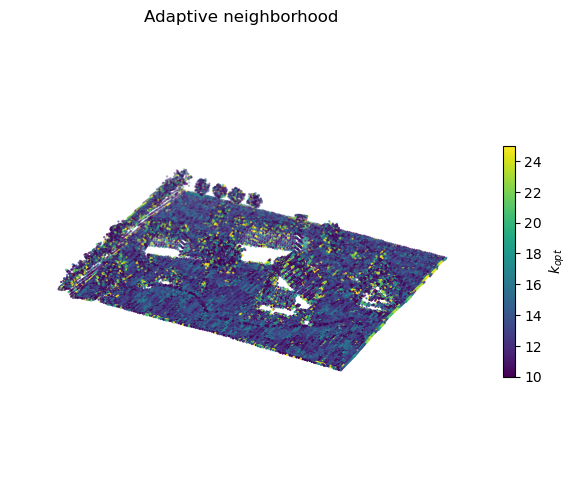

In [10]:
# Compute k_opt
neighbor_finder = lambda points, k: kdtree.query(points, k, return_distance=False)
k_opt = compute_adaptive_neighborhoods(points, neighbor_finder, k_max=25, k_step=1)

# Visualize the test pointcloud colored by k_opt
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                     c=k_opt, cmap="viridis", s=0.5)
fig.colorbar(scatter, ax=ax, label="$k_{opt}$", shrink=0.5)
ax.set_aspect("equal")
ax.view_init(elev=30)
ax.set_axis_off()
ax.set_title("Adaptive neighborhood")
plt.show()

In practice, **multi-scale neighborhoods remain the most effective and popular strategy**, because they capture geometry at different levels of detail. A common baseline is to **use 3 to 6 scales with a logarithmic progression**, small scales capturing local geometry, medium scales describing object parts, and larger scales providing full object context.

In the case of airborne LiDAR pointclouds such as the one presented above, **k-neighborhoods are generally preferred** since they better handle density variations and result in more stable features. Considering its moderate density (10 pts/m², giving about 30 cm point spacing), a good starting point is $k = [10, 20, 50]$. Indeed, these values roughly correspond to scales from 0.3 m to 2 m. This provides a good coverage of the scene, from ground surfaces to buildings and vegetation.

Of course, these neighborhoods may be refined later based on classification results.

In [11]:
# k values used for multiscale neighborhoods
k_values_multiscale = [10, 20, 50]

### Descriptors

The second key step of semantic segmentation pipeline is the **computation of descriptors** or features.

Common types of features include:

* **Eigenvalue-based features** (e.g., linearity, planarity, scattering), capturing the local 3D shape.

* **Height-based features** (e.g., height above ground, height range), describing vertical positioning.

* **Density-based features** (e.g., point density, spacing), representing how points are distributed locally in space.

* **Angle-based features** (e.g., verticality, normal variation), characterizing surface orientation and smoothness.

* **Histogram-based features** (e.g., PFH, SHOT), capturing complex local patterns.

* **Radiometric features** (e.g., intensity, intensity statistics), linked to material properties (when available from LiDAR).

* **RGB features** (e.g., color gradients and statistics), incorporating color information (when available).

Additionally, some of these descriptors can also be computed from a 2D projection (e.g. onto the ground plane), which provides complementary information in structured environments.

Implementations of some of the most used descriptors in semantic segmentation are proposed below. Height, density and angle-based features are grouped into the "geometric features" category and both 3D and 2D descriptors are considered.

These implementations below compute the $k$ nearest neighbors for all points at once and use vectorized operations whenever possible instead of explicit loops. Again, this approach is memory-intensive and switching to batch processing is advised for large pointclouds. Separate functions are used for each category of features (i.e., 3D and 2D eigenvalue-based features, as well as 3D and 2D geometric features) for clarity and readability, although grouping them would reduce redundant neighborhood computations. The ```indices``` parameter enables descriptor computation on a subset of points only (useful for adaptive neighborhoods for example).

In [12]:
def compute_3D_eigen_features(points, neighbor_finder, norm_eigenvalues=True, indices=None):
    """"Compute normals and principal eigenvalue-based features."""

    # Neighbors for all query points
    query_points = points if indices is None else points[indices]
    inds = neighbor_finder(query_points) # (N, k)
    k = inds.shape[-1]
    neighbors = points[inds]
    # Eigenvalues from covariance matrix
    neighbors -= neighbors.mean(axis=1, keepdims=True) # center in-place
    cov = (neighbors.transpose(0, 2, 1) @ neighbors) / k  # (N, 3, 3)
    eigenvalues, eigenvectors = np.linalg.eigh(cov) # (N, 3), (N, 3, 3)
    eigenvalues = np.clip(eigenvalues, 1e-10, None) # fix numerical negatives
    # Normals
    normals = eigenvectors[:,:,0]
    # Compute sum before normalization (equal to 1. if normalized)
    eigensum = eigenvalues.sum(axis=1)
    # Normalize eigenvalues if required
    if norm_eigenvalues:
        eigenvalues /= eigenvalues.sum(axis=1, keepdims=True)
    # Compute features based on eigenvalues
    lambda_1 = eigenvalues[:, 2]
    lambda_2 = eigenvalues[:, 1]
    lambda_3 = eigenvalues[:, 0]
    linearity = (lambda_1 - lambda_2) / lambda_1
    planarity = (lambda_2 - lambda_3) / lambda_1
    scattering = lambda_3 / lambda_1
    omnivariance = (lambda_1 * lambda_2 * lambda_3) ** (1/3)
    anisotropy = (lambda_1 - lambda_3) / lambda_1
    eigentropy = -np.sum(eigenvalues * np.log(eigenvalues), axis=1)
    curvature = lambda_3 / (lambda_1 + lambda_2 + lambda_3)

    return (normals, linearity, planarity, scattering, omnivariance, 
            anisotropy, eigentropy, eigensum, curvature)

The 3D eigenvalue-based features have already been introduced in the previous notebook on descriptors. One important thing to remember is that the eigensum should not be normalized. If so, its value becomes the same (equal to 1) for every point, which is not useful for training or prediction.

Normals are computed at the same time and at different scales. Another option is to compute normals separately as a preprocessing step, using a different (adaptive) scale, as shown in the notebook about normals and curvatures. For aerial data, normals can be easily oriented using the sensor position and direction, so they point upward (toward $z^{+}$).

In [13]:
# Compute normals and 3D eigenvalue-based features
normals_multiscale = []
eigenfeatures_3D_multiscale = []
eigenfeatures_3D_names = []

for k in k_values_multiscale:
    neighbor_finder = lambda points: kdtree.query(points, 
                                                  k,
                                                  return_distance=False)
    eigenfeatures_3D_k = compute_3D_eigen_features(points, neighbor_finder)
    # Remove normals from eigenfeatures list (computed at same time)
    normals_k, eigenfeatures_3D_k = eigenfeatures_3D_k[0], eigenfeatures_3D_k[1:]
    # Orient normals consistently towards +z direction (acquisition direction)
    mask_n = normals_k[:, 2] < 0
    normals_k[mask_n] = -normals_k[mask_n]
    # Store results
    normals_multiscale.append(normals_k)
    eigenfeatures_3D_multiscale.append(eigenfeatures_3D_k)
    eigenfeatures_3D_names.extend([
        f"linearity_{k}", f"planarity_{k}", f"scattering_{k}", f"omnivariance_{k}", 
        f"anisotropy_{k}", f"eigentropy_{k}", f"eigensum_{k}", f"curvature_{k}"
    ])

# Concatenate all multiscale features in one array of shape (N, 8*k)
eigenfeatures_3D_multiscale = np.stack(
    [arr for tup in eigenfeatures_3D_multiscale for arr in tup],
    axis=1
)

Contrary to eigenvalue-based features, geometric features capture the global or contextual position  of each point in the scene, rather than the local shape of its neighborhood. The tables below list some of the most used height-based, density-based and angle-based features.

Height-based features assume a prefered direction for height, often $z$. Features are computed withing each neighborhood but also relatively to the ground thanks to a Digital Terrain Model (DTM), which represents the bare-earth surface. A DTM is typically created as a preprocessing step by extracting ground points from the data and building a surface that represents the terrain height (not covered here). Height-based features typically help to capture elevated objects such as buildings or vegetation.

| Feature           | Formula             | Intuitive meaning                    |
|-------------------|---------------------|--------------------------------------|
| Normalized height | $z - z_{ground}$    | Height relative to ground (need DTM) |
| Height variation  | $std (z)$           | Height variation within neighborhood |
| Height range      | $z_{max} - z_{min}$ | Height range within neighborhood     |  

Density-based features describe how points are distributed in space. They provide information about how crowded or sparse a local region is, which can help differentiate between solid structures and more irregular or scattered objects.

| Feature                | Formula                     | Intuitive meaning                     |
|------------------------|-----------------------------|---------------------------------------|
| Density                | $k / \frac{4}{3} \pi r^{3}$ | Local density                         |
| Radius (knn distance)  | $r = d_{knn}$               | Size of the local neighborhood        |
| Mean neighbor distance | $1/k \sum d_i$              | Average spacing between nearby points |

Angle-based features rely on the orientation of the local surface, typically derived from normal vectors. They capture how much local surface varies in orientation, making it easier to identify horizontal/vertical or highly irregular structures.
 
| Feature           | Formula         | Intuitive meaning                  |
|-------------------|-----------------|------------------------------------|
| Verticality       | $1 - \|n_{z}\|$ | How "upright" the local surface is |
| Angular variation | $std (n)$       | Variation of surface orientation   |


In [14]:
def compute_3D_geometric_features(points, normals, neighbor_finder, indices=None):
    """Compute 3D features"""

    # Neighbors for all query points
    query_points = points if indices is None else points[indices]
    query_normals = normals if indices is None else normals[indices]
    dists, inds = neighbor_finder(query_points)  # (N, k)
    k = inds.shape[-1]
    # Density
    radius = dists[:, -1]
    density = k / ((4/3) * np.pi * radius**3)
    mean_dists = np.mean(dists, axis=1)
    # Height
    knn_z_coords = points[inds, 2] # (N, k)
    d_z = knn_z_coords.max(axis=1) - knn_z_coords.min(axis=1)
    std_z = knn_z_coords.std(axis=1)
    # Angle (normals are supposed to be oriented, otherwise use abs)
    verticality = 1 - np.abs(query_normals[:, 2])
    normals_dot = np.sum(query_normals[:, None, :] * normals[inds], axis=2) # (N, k)
    normals_dot = np.clip(normals_dot, -1.0, 1.0)
    angular_variation = np.mean(1 - normals_dot, axis=1)

    return radius, density, mean_dists, d_z, std_z, verticality, angular_variation


In [15]:
# 3D geometric features
geomfeatures_3D_multiscale = []
geomfeatures_3D_names = []

for i, k in enumerate(k_values_multiscale):
    neighbor_finder = lambda points: kdtree.query(points, 
                                                  k,
                                                  return_distance=True,
                                                  sort_results=True)
    
    geomfeatures_3D_k = compute_3D_geometric_features(points,
                                                      normals_multiscale[i],
                                                      neighbor_finder)
    # Store results
    geomfeatures_3D_multiscale.append(geomfeatures_3D_k)
    geomfeatures_3D_names.extend([
        f"radius_{k}", f"density_{k}", f"mean_dists_{k}", f"d_z_{k}",
        f"std_z_{k}", f"verticality_{k}", f"angular_variation_{k}"
    ])

# Concatenate all multiscale features in one array of shape (N, 7*k)
geomfeatures_3D_multiscale = np.stack(
    [arr for tup in geomfeatures_3D_multiscale for arr in tup],
    axis=1
)

Finally all features are concatenated. Intensity is also used.

In [22]:
# All available features
X_all = np.concatenate(
    [eigenfeatures_3D_multiscale, geomfeatures_3D_multiscale, intensity[:, None]],
    axis=1
)
X_names_all = np.array(eigenfeatures_3D_names + geomfeatures_3D_names + ["intensity"])

print("Shape of X_all:", X_all.shape)
print("Feature names:", X_names_all)


Shape of X_all: (49056, 46)
Feature names: ['linearity_10' 'planarity_10' 'scattering_10' 'omnivariance_10'
 'anisotropy_10' 'eigentropy_10' 'eigensum_10' 'curvature_10'
 'linearity_20' 'planarity_20' 'scattering_20' 'omnivariance_20'
 'anisotropy_20' 'eigentropy_20' 'eigensum_20' 'curvature_20'
 'linearity_50' 'planarity_50' 'scattering_50' 'omnivariance_50'
 'anisotropy_50' 'eigentropy_50' 'eigensum_50' 'curvature_50' 'radius_10'
 'density_10' 'mean_dists_10' 'd_z_10' 'std_z_10' 'verticality_10'
 'angular_variation_10' 'radius_20' 'density_20' 'mean_dists_20' 'd_z_20'
 'std_z_20' 'verticality_20' 'angular_variation_20' 'radius_50'
 'density_50' 'mean_dists_50' 'd_z_50' 'std_z_50' 'verticality_50'
 'angular_variation_50' 'intensity']


One issue is the strong imbalance between ground and the other classes.

It may be mitigated by performing **class rebalancing** on the training set (the test set remains imbalanced to reflect real-world conditions) through **random undersampling**. 

Specifically, it constructs a new dataset by selecting the same number of samples for each class, which results in a balanced dataset referred to as the *reduced training set*.

In practice, this means that most of the points from dominant classes such as ground are discarded.

The balanced training set is not only used for classifier training but also for feature selection, since performing feature selection on imbalanced data would bias the process toward features that mainly discriminate the majority class.

The approach has the advantage of being simple and compatible with any classifier. However, it comes at the cost of a significant loss of information, especially for the ground class, since most of its data is removed.

Other strategies could have been used, such as class weighting or data augmentation for minority classes, but these are not explored in this work.

In [23]:
def random_undersample_balance(X_train, y_train, n_samples_per_class=None, random_state=42):
    """Perform random undersampling to balance classes."""
    
    classes = np.unique(y_train)
    # Determine target number of samples per class
    if n_samples_per_class is None:
        class_counts = [np.sum(y_train==c) for c in classes]
        n_samples_per_class = min(class_counts)
    X_list = []
    y_list = []

    for c in classes:
        X_c = X_train[y_train==c]
        y_c = y_train[y_train==c]
        # Random undersampling
        X_resampled, y_resampled = resample(X_c, y_c, replace=False,
            n_samples=n_samples_per_class, random_state=random_state)
        X_list.append(X_resampled)
        y_list.append(y_resampled)

    # Concatenate all classes
    X_balanced = np.vstack(X_list)
    y_balanced = np.concatenate(y_list)
    # Mix classes
    perm = np.random.RandomState(random_state).permutation(len(y_balanced))
    X_balanced = X_balanced[perm]
    y_balanced = y_balanced[perm]

    return X_balanced, y_balanced


In [24]:
# Balance dataset
X_balanced, y_balanced = random_undersample_balance(X_all, y_train)

print("Original shape:", X_all.shape)
print("Balanced shape:", X_balanced.shape)
print("Class distribution:", {int(c): int(np.sum(y_balanced==c)) 
                              for c in np.unique(y_balanced)})


Original shape: (49056, 46)
Balanced shape: (18726, 46)
Class distribution: {0: 6242, 1: 6242, 2: 6242}


Feature selection

Select a subset of relevant features only.

Classical machine learning, not specific to pointcloud semantic segmentation.

Global takeway is that 3D eigenfeatures alone are not optimal.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr = np.corrcoef(X, rowvar=False)
        
        self.to_remove_ = set()

        for i in range(corr.shape[0]):
            for j in range(i + 1, corr.shape[0]):
                if abs(corr[i, j]) > self.threshold:
                    self.to_remove_.add(j)

        # ✅ on construit et stocke le masque proprement
        self.mask_ = np.array([i not in self.to_remove_ for i in range(X.shape[1])])

        return self

    def transform(self, X):
        return X[:, self.mask_]

    def get_support(self):
        return self.mask_



k = 25
corr_threshold = 0.9

# SelectKBest
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_kbest = selector.fit_transform(X_balanced, y_balanced)

mask_kbest = selector.get_support()
indices_kbest = np.where(mask_kbest)[0]

print("Remaining after KBest:", X_names_all[indices_kbest])

# CorrelationFilter
corr_filter = CorrelationFilter(threshold=corr_threshold)
X_final = corr_filter.fit_transform(X_kbest)

mask_corr = corr_filter.get_support()

# projection dans l’espace original
indices_final = indices_kbest[mask_corr]

print("Remaining after correlation filter:", X_names_all[indices_final])


Remaining after KBest: ['scattering_10' 'omnivariance_10' 'anisotropy_10' 'curvature_10'
 'scattering_20' 'omnivariance_20' 'anisotropy_20' 'curvature_20'
 'scattering_50' 'omnivariance_50' 'anisotropy_50' 'eigentropy_50'
 'curvature_50' 'd_z_10' 'std_z_10' 'verticality_10'
 'angular_variation_10' 'd_z_20' 'std_z_20' 'verticality_20' 'd_z_50'
 'std_z_50' 'verticality_50' 'angular_variation_50' 'intensity']
Remaining after correlation filter: ['scattering_10' 'omnivariance_10' 'scattering_20' 'scattering_50'
 'd_z_10' 'verticality_10' 'angular_variation_10' 'verticality_20'
 'd_z_50' 'verticality_50' 'angular_variation_50' 'intensity']


### Classifiers

The third key step of the semantic segmentation pipeline is the **selection and tuning of a classifier**

The list of possible classifiers is potentially large, but in practice a few ones are used most frequently: *Random Forest* (RF) and *Gradient Boosting Trees* (GBT).

A clear practical takeaway is that **Random Forest (RF) stands out as a widely adopted baseline**, consistently providing good performance with minimal parameter tuning. It is robust to noise, capable of handling high-dimensional feature spaces, and resistant to overfitting. It also provides feature importance measures, which are useful for analysing and improving descriptors. Importantly, it does not require feature normalization and handles class imbalance reasonably well. Finally, its parallelizable and many efficient implementations are available.

More generally, **the impact of the classifier choice is often secondary compared to the quality of the input features**. While alternatives such as *Support Vector Machines* (SVM) can achieve similar results as RF, they typically require more careful tuning and do not scale as efficiently to large datasets. Simpler methods like *k‑Nearest Neighbors* (kNN) or probabilistic models are less frequently used in practice due to computational limitations or lower robustness. As a result, ensemble-based methods such RF and GBT, which provide a good trade-off between accuracy, scalability, and ease of deployment, are generally preferred in real-world scenarios.

The implementation below uses ```scikit-learn``` implementation of ```RandomForestClassifier``` with default settings. A number of trees of 100 is already a good choice, but it is also possible to go higher (e.g., from 200 to 500) for better stability. The model achieves perfect performance on the training set. This likely indicates overfitting and reflects the simplicity of the classification problem (three well-separated classes) rather than true generalization performance.

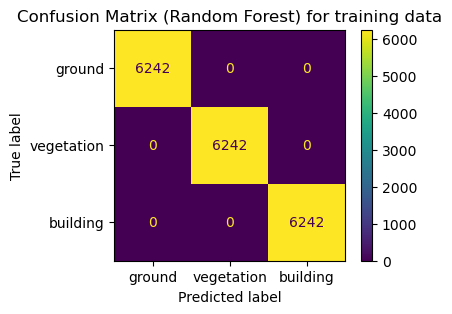

In [27]:
# Feature matrix for classification
X_train = X_balanced[:, indices_final]
y_train = y_balanced
X_train_names = X_names_all[indices_final]

# Train a Random Forest classifier
rf_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_clf.fit(X_train, y_train)

# Evaluate the classifier using a confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
cmd_clf = ConfusionMatrixDisplay.from_estimator(
    rf_clf,
    X_train,
    y_train,
    display_labels=class_names.values(),
    ax=ax
)
ax.set_title("Confusion Matrix (Random Forest) for training data")
plt.show()

As stated above, feature importances (i.e., how much each input variable contributes to a model’s predictions) is provided directly by the RF classifier via ```model.feature_importances_```. The standard measure for RF is the *Mean Decrease in Impurity* (MDI): each time a feature is used to split a node in a tree, it reduces impurity (e.g., Gini), and these reductions are accumulated and averaged across all trees to produce an importance score. MDI is computationally efficient, but it can be biased when features are highly correlated or differ in scale or number of categories.

As alternative is permutation importance (```sklearn.inspection.permutation_importance```), which estimates feature importance by measuring the decrease in model performance when the values of a feature are randomly shuffled. This approach is generally more reliable and model-agnostic, but comes at a higher computational cost.

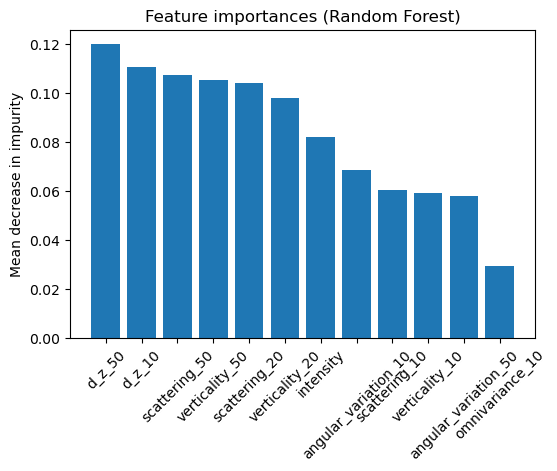

In [28]:
# Compute feature importances and sort
clf_feature_importances = rf_clf.feature_importances_
sorted_inds = np.argsort(clf_feature_importances)[::-1]

# Plot feature importances
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(clf_feature_importances)), clf_feature_importances[sorted_inds])
ax.set_xticks(range(len(clf_feature_importances)))
ax.set_xticklabels(X_train_names[sorted_inds], rotation=45)
ax.set_ylabel("Mean decrease in impurity")
ax.set_title("Feature importances (Random Forest)")
plt.show()


Test data

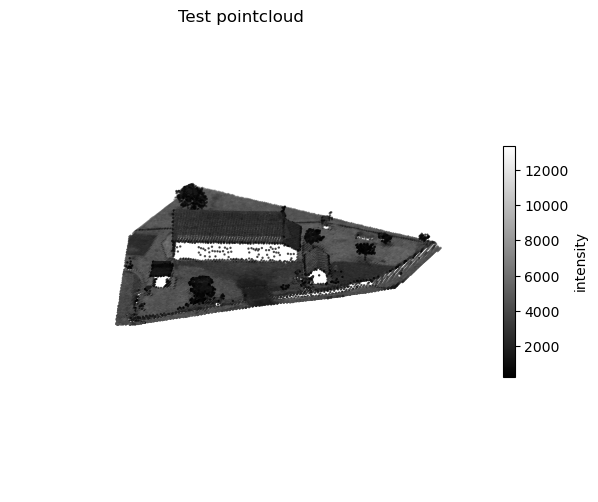

In [29]:
# Load test pointcloud and compute features (similar to training)
data_test = np.loadtxt("./data/LHD_test.xyz")
points, intensity, y_test = data_test[:, :3], data_test[:, 3], data_test[:, 4]

# Spatial structure
kdtree = KDTree(points)

# Visualize the test pointcloud colored by intensity
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                     c=intensity, cmap="gray", s=0.5)
fig.colorbar(scatter, ax=ax, label="intensity", shrink=0.5)
ax.set_aspect("equal")
ax.view_init(elev=30)
ax.set_axis_off()
ax.set_title("Test pointcloud")
plt.show()


In [30]:
normals_multiscale = []
eigenfeatures_3D_multiscale = []

for k in k_values_multiscale:
    neighbor_finder = lambda points: kdtree.query(points, 
                                                  k,
                                                  return_distance=False)
    eigenfeatures_3D_k = compute_3D_eigen_features(points, neighbor_finder)
    # Remove normals from eigenfeatures list (computed at same time)
    normals_k, eigenfeatures_3D_k = eigenfeatures_3D_k[0], eigenfeatures_3D_k[1:]
    # Orient normals consistently towards +z direction (acquisition direction)
    mask_n = normals_k[:, 2] < 0
    normals_k[mask_n] = -normals_k[mask_n]
    # Store results
    normals_multiscale.append(normals_k)
    eigenfeatures_3D_multiscale.append(eigenfeatures_3D_k)

# Concatenate all multiscale features in one array of shape (N, 8*k)
eigenfeatures_3D_multiscale = np.stack(
    [arr for tup in eigenfeatures_3D_multiscale for arr in tup],
    axis=1
)

In [31]:
geomfeatures_3D_multiscale = []

for i, k in enumerate(k_values_multiscale):
    neighbor_finder = lambda points: kdtree.query(points, 
                                                  k,
                                                  return_distance=True,
                                                  sort_results=True)
    
    geomfeatures_3D_k = compute_3D_geometric_features(points,
                                                      normals_multiscale[i],
                                                      neighbor_finder)
    # Store results
    geomfeatures_3D_multiscale.append(geomfeatures_3D_k)

# Concatenate all multiscale features in one array of shape (N, 7*k)
geomfeatures_3D_multiscale = np.stack(
    [arr for tup in geomfeatures_3D_multiscale for arr in tup],
    axis=1
)


In [32]:
X_all_test = np.concatenate(
    [eigenfeatures_3D_multiscale, geomfeatures_3D_multiscale, intensity[:, None]],
    axis=1
)
X_test = X_all_test[:, indices_final]

print(X_test.shape)

(32901, 12)


              precision    recall  f1-score   support

      ground       0.98      0.96      0.97     25236
  vegetation       0.71      0.91      0.80      2585
    building       0.92      0.91      0.91      5080

    accuracy                           0.95     32901
   macro avg       0.87      0.92      0.89     32901
weighted avg       0.95      0.95      0.95     32901



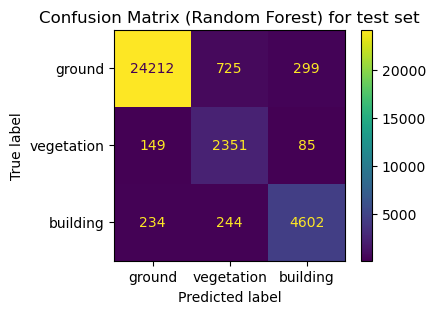

In [33]:
# Predict class labels for the test set
y_pred = rf_clf.predict(X_test)

# Classification report
print(
    classification_report(y_test, y_pred, target_names=class_names.values())
)

# Evaluate the classifier using a confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
cmd_clf = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=class_names.values(),
    ax=ax
)
ax.set_title("Confusion Matrix (Random Forest) for test set")
plt.show()

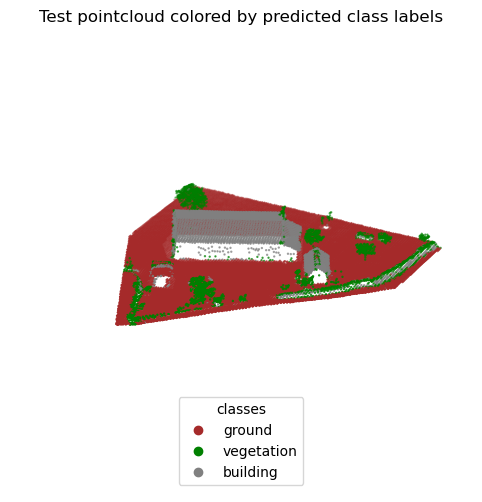

In [34]:
# Plot predicted labels on the test pointcloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=y_pred, cmap=lidar_cmap, s=0.5)
ax.set_aspect("equal")
ax.view_init(elev=30)
ax.set_axis_off()
ax.set_title("Test pointcloud colored by predicted class labels")
# Create legend with class names
ax.legend(legend_handles, legend_labels, title="classes", loc="lower center")
plt.show()

## Wrapping up